<a href="https://colab.research.google.com/github/williamadigun/EMBEDDED/blob/main/Welcome_to_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import os
import zipfile
import shutil
from google.colab import files

print("📂 STEP 1: Select your ZIP files to upload:")
uploaded_files = files.upload()

extraction_target_dir = './extracted_dataset'
os.makedirs(extraction_target_dir, exist_ok=True)

# Process files
for filename in uploaded_files.keys():
    if filename.endswith('.zip'):
        print(f"📦 Extracting archive: {filename}...")
        with zipfile.ZipFile(filename, 'r') as zip_ref:
            zip_ref.extractall(extraction_target_dir)
        os.remove(filename) # Remove raw zip file to save disk storage space

# Strip out hidden system clutter like macOS metadata files
for root, dirs, files_in_dir in os.walk(extraction_target_dir, topdown=False):
    if '__MACOSX' in root:
        shutil.rmtree(root)
        continue
    for file in files_in_dir:
        if file.startswith('.') or file.lower() == 'thumbs.db':
            os.remove(os.path.join(root, file))

print("\n✅ Step 1 Complete: Dataset unpacked clean.")

📂 STEP 1: Select your ZIP files to upload:


Saving archive (4).zip to archive (4).zip
📦 Extracting archive: archive (4).zip...

✅ Step 1 Complete: Dataset unpacked clean.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [5]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Optimized for CPU processing efficiency
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16  # Smaller batch size prevents CPU memory congestion

# Image transforms
train_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Generate target datasets based on extracted directory structure
full_dataset = datasets.ImageFolder(root='./extracted_dataset')
total_count = len(full_dataset)
class_names = full_dataset.classes

# Split 80% Train / 20% Validation
train_size = int(0.8 * total_count)
val_size = total_count - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size],
                                          generator=torch.Generator().manual_seed(42))

train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform

# Create Loaders (num_workers=0 is optimal for stable CPU training inside Colab)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("==================================================")
print(f"✅ STEP 2 COMPLETE: Data Loaders Assembled")
print(f" ├─ Found Classes: {class_names}")
print(f" ├─ Training Samples: {len(train_dataset)}")
print(f" └─ Validation Samples: {len(val_dataset)}")
print("==================================================")

✅ STEP 2 COMPLETE: Data Loaders Assembled
 ├─ Found Classes: ['Mice', 'Rats', 'Shrew', 'human detection dataset']
 ├─ Training Samples: 2264
 └─ Validation Samples: 566


In [6]:
import torch.nn as nn
import torchvision.models as models

# Explicitly lock processing to CPU execution
device = torch.device("cpu")
print(f"🖥️ STEP 3: Initializing model structure on environment device: {device}")

# Load Pre-trained ResNet18 Network
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze convolutional features so the CPU doesn't have to optimize millions of weights
for param in model.parameters():
    param.requires_grad = False

# Customize the final classification output layer to match your classes count
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, len(class_names))
)

# Bind model framework to CPU
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

print("✅ Step 3 Complete: Neural Network parameters mapped cleanly to CPU.")

🖥️ STEP 3: Initializing model structure on environment device: cpu
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 109MB/s]


✅ Step 3 Complete: Neural Network parameters mapped cleanly to CPU.


In [7]:
import time

EPOCHS = 5  # Adjusted down to 5 epochs for practical CPU timeline management
best_val_acc = 0.0

print("🚀 STEP 4: Commencing CPU-Based Sequential Training Loop...")
print("==================================================")

for epoch in range(EPOCHS):
    start_time = time.time()

    # --- TRAINING PHASE ---
    model.train()
    running_loss, running_corrects, total_samples = 0.0, 0, 0
    total_batches = len(train_loader)

    for batch_idx, (inputs, labels) in enumerate(train_loader, 1):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        total_samples += inputs.size(0)

        # Live batch monitoring for transparency during slower CPU processing
        if batch_idx % 2 == 0 or batch_idx == total_batches:
            print(f"   ⏳ Epoch [{epoch+1}/{EPOCHS}] | Batch [{batch_idx}/{total_batches}] processed. Loss: {loss.item():.4f}")

    epoch_train_loss = running_loss / total_samples
    epoch_train_acc = (running_corrects.double() / total_samples) * 100

    # --- VALIDATION PHASE ---
    model.eval()
    running_val_loss, running_val_corrects, total_val_samples = 0.0, 0, 0

    print("   🔎 Running validation evaluation checks...")
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

            running_val_loss += loss.item() * inputs.size(0)
            running_val_corrects += torch.sum(preds == labels.data)
            total_val_samples += inputs.size(0)

    epoch_val_loss = running_val_loss / total_val_samples
    epoch_val_acc = (running_val_corrects.double() / total_val_samples) * 100

    print(f"\n🔄 Epoch {epoch+1}/{EPOCHS} Finished | Runtime: {time.time() - start_time:.1f}s")
    print(f"   ├── Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}%")
    print(f"   └── Val Loss:   {epoch_val_loss:.4f} | Val Acc:   {epoch_val_acc:.2f}%")
    print("-" * 50)

    # Save parameters if accuracy checks out performant
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), 'best_model_weights.pth')

print("==================================================")
print(f"🏁 PIPELINE RUN COMPLETE! Target optimized weights saved to root workspace.")

🚀 STEP 4: Commencing CPU-Based Sequential Training Loop...
   ⏳ Epoch [1/5] | Batch [2/142] processed. Loss: 1.3518
   ⏳ Epoch [1/5] | Batch [4/142] processed. Loss: 1.3593
   ⏳ Epoch [1/5] | Batch [6/142] processed. Loss: 1.2371
   ⏳ Epoch [1/5] | Batch [8/142] processed. Loss: 0.9897
   ⏳ Epoch [1/5] | Batch [10/142] processed. Loss: 0.7863
   ⏳ Epoch [1/5] | Batch [12/142] processed. Loss: 0.7489
   ⏳ Epoch [1/5] | Batch [14/142] processed. Loss: 1.0511
   ⏳ Epoch [1/5] | Batch [16/142] processed. Loss: 0.7830
   ⏳ Epoch [1/5] | Batch [18/142] processed. Loss: 1.0348
   ⏳ Epoch [1/5] | Batch [20/142] processed. Loss: 0.6832
   ⏳ Epoch [1/5] | Batch [22/142] processed. Loss: 0.6280
   ⏳ Epoch [1/5] | Batch [24/142] processed. Loss: 0.7280
   ⏳ Epoch [1/5] | Batch [26/142] processed. Loss: 0.9656
   ⏳ Epoch [1/5] | Batch [28/142] processed. Loss: 0.5865
   ⏳ Epoch [1/5] | Batch [30/142] processed. Loss: 0.6848
   ⏳ Epoch [1/5] | Batch [32/142] processed. Loss: 0.5850
   ⏳ Epoch [1/5] 

In [8]:
import torch
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
from PIL import Image
from google.colab import files

def predict_new_image():
    # 1. Set backend to CPU
    device = torch.device("cpu")

    # 2. Rebuild the exact model structure used during training
    inference_model = models.resnet18()
    num_features = inference_model.fc.in_features
    inference_model.fc = nn.Sequential(
        nn.Linear(num_features, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, len(class_names)) # Reads dynamically from your Step 2 data loader
    )

    # 3. Load your saved training weights
    try:
        inference_model.load_state_dict(torch.load('best_model_weights.pth', map_location=device))
        inference_model.eval() # Set model to evaluation mode
        print("💾 Trained weights successfully loaded into model structure.")
    except FileNotFoundError:
        print("❌ Error: 'best_model_weights.pth' not found. Please make sure Step 4 completed successfully.")
        return

    # 4. Trigger file upload widget for your test image
    print("\n📸 Upload an image to test your model's classification prediction:")
    uploaded = files.upload()

    if not uploaded:
        print("❌ No image file selected.")
        return

    img_path = list(uploaded.keys())[0]

    # 5. Preprocess the image exactly like the validation set
    eval_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    raw_image = Image.open(img_path).convert('RGB')
    input_tensor = eval_transform(raw_image).unsqueeze(0) # Add batch dimension [1, 3, 224, 224]

    # 6. Run prediction pass
    with torch.no_grad():
        outputs = inference_model(input_tensor)
        probabilities = torch.nn.functional.softmax(outputs[0], dim=0)
        confidence, class_idx = torch.max(probabilities, 0)

    predicted_label = class_names[class_idx.item()]

    # 7. Print the final visual summary
    print("\n==================================================")
    print("              MODEL INFERENCE RESULT              ")
    print("==================================================")
    print(f"🎯 Predicted Category:  👉 {predicted_label} 👈")
    print(f"🛡️ Confidence Score:    {confidence.item() * 100:.2f}%")
    print("==================================================")

# Run the inference block
predict_new_image()


💾 Trained weights successfully loaded into model structure.

📸 Upload an image to test your model's classification prediction:


Saving 20260121_160844.jpg.jpeg to 20260121_160844.jpg.jpeg

              MODEL INFERENCE RESULT              
🎯 Predicted Category:  👉 human detection dataset 👈
🛡️ Confidence Score:    79.96%


💾 Trained weights successfully loaded into model structure.

📸 Upload an image to test your model's classification prediction:


Saving images (7).jpg to images (7) (1).jpg

              MODEL INFERENCE RESULT              
🎯 Predicted Category:  👉 Mice 👈
🛡️ Confidence Score:    55.17%



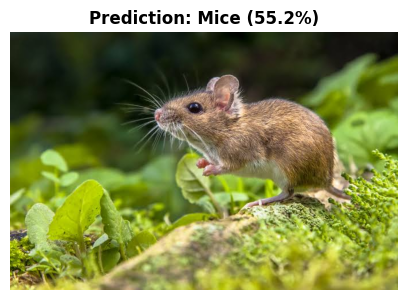

In [19]:
import torch
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
from PIL import Image
from google.colab import files
import matplotlib.pyplot as plt  # Added for rendering the image inline

def predict_new_image():
    # 1. Set backend to CPU
    device = torch.device("cpu")

    # 2. Rebuild the exact model structure used during training
    inference_model = models.resnet18()
    num_features = inference_model.fc.in_features
    inference_model.fc = nn.Sequential(
        nn.Linear(num_features, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, len(class_names)) # Reads dynamically from your Step 2 data loader
    )

    # 3. Load your saved training weights
    try:
        inference_model.load_state_dict(torch.load('best_model_weights.pth', map_location=device))
        inference_model.eval() # Set model to evaluation mode
        print("💾 Trained weights successfully loaded into model structure.")
    except FileNotFoundError:
        print("❌ Error: 'best_model_weights.pth' not found. Please make sure Step 4 completed successfully.")
        return

    # 4. Trigger file upload widget for your test image
    print("\n📸 Upload an image to test your model's classification prediction:")
    uploaded = files.upload()

    if not uploaded:
        print("❌ No image file selected.")
        return

    img_path = list(uploaded.keys())[0]

    # 5. Preprocess the image exactly like the validation set
    eval_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    raw_image = Image.open(img_path).convert('RGB')
    input_tensor = eval_transform(raw_image).unsqueeze(0) # Add batch dimension [1, 3, 224, 224]

    # 6. Run prediction pass
    with torch.no_grad():
        outputs = inference_model(input_tensor)
        probabilities = torch.nn.functional.softmax(outputs[0], dim=0)
        confidence, class_idx = torch.max(probabilities, 0)

    predicted_label = class_names[class_idx.item()]

    # 7. Print the final visual summary
    print("\n==================================================")
    print("              MODEL INFERENCE RESULT              ")
    print("==================================================")
    print(f"🎯 Predicted Category:  👉 {predicted_label} 👈")
    print(f"🛡️ Confidence Score:    {confidence.item() * 100:.2f}%")
    print("==================================================\n")

    # 8. Render the uploaded image with matplotlib
    plt.figure(figsize=(5, 5))
    plt.imshow(raw_image)
    plt.title(f"Prediction: {predicted_label} ({confidence.item() * 100:.1f}%)", fontsize=12, fontweight='bold')
    plt.axis('off')  # Hide grid axis lines for a clean presentation look
    plt.show()

# Run the inference block
predict_new_image()

💾 Trained weights successfully loaded into model structure.

📸 Upload an image to test your model's classification prediction:


Saving 23 a.jpg to 23 a (1).jpg

              MODEL INFERENCE RESULT              
🎯 Predicted Category:  👉  Shrew  👈
🛡️ Raw Network Match:    72.75%



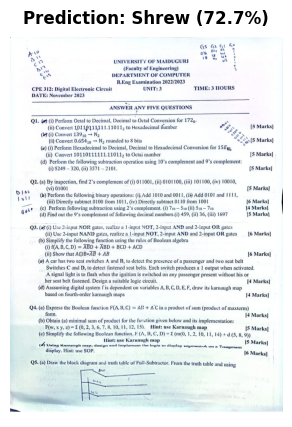

In [12]:
import torch
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
from PIL import Image
from google.colab import files
import matplotlib.pyplot as plt

def predict_new_image():
    # 1. Set backend to CPU
    device = torch.device("cpu")

    # 2. Rebuild the exact model structure used during training
    inference_model = models.resnet18()
    num_features = inference_model.fc.in_features
    inference_model.fc = nn.Sequential(
        nn.Linear(num_features, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, len(class_names)) # Reads dynamically from your Step 2 data loader
    )

    # 3. Load your saved training weights
    try:
        inference_model.load_state_dict(torch.load('best_model_weights.pth', map_location=device))
        inference_model.eval() # Set model to evaluation mode
        print("💾 Trained weights successfully loaded into model structure.")
    except FileNotFoundError:
        print("❌ Error: 'best_model_weights.pth' not found. Please make sure Step 4 completed successfully.")
        return

    # 4. Trigger file upload widget for your test image
    print("\n📸 Upload an image to test your model's classification prediction:")
    uploaded = files.upload()

    if not uploaded:
        print("❌ No image file selected.")
        return

    img_path = list(uploaded.keys())[0]

    # 5. Preprocess the image exactly like the validation set
    eval_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    raw_image = Image.open(img_path).convert('RGB')
    input_tensor = eval_transform(raw_image).unsqueeze(0) # Add batch dimension

    # 6. Run prediction pass
    with torch.no_grad():
        outputs = inference_model(input_tensor)
        probabilities = torch.nn.functional.softmax(outputs[0], dim=0)
        confidence, class_idx = torch.max(probabilities, 0)

    # ---------------------------------------------------------------------
    # SECURITY ANOMALY FILTER (THRESHOLD RUN)
    # ---------------------------------------------------------------------
    CONFIDENCE_THRESHOLD = 0.70  # 70% threshold. Adjust this based on testing!
    confidence_pct = confidence.item() * 100

    if confidence.item() < CONFIDENCE_THRESHOLD:
        predicted_label = "VOID"
        display_title = f"Result: VOID (Low Confidence: {confidence_pct:.1f}%)"
    else:
        predicted_label = class_names[class_idx.item()]
        display_title = f"Prediction: {predicted_label} ({confidence_pct:.1f}%)"

    # 7. Print the final visual summary
    print("\n==================================================")
    print("              MODEL INFERENCE RESULT              ")
    print("==================================================")
    if predicted_label == "VOID":
        print(f"⚠️ Result:               👉  {predicted_label}  👈")
        print(f"ℹ️ Status:               Object falls outside dataset boundaries.")
    else:
        print(f"🎯 Predicted Category:  👉  {predicted_label}  👈")
    print(f"🛡️ Raw Network Match:    {confidence_pct:.2f}%")
    print("==================================================\n")

    # 8. Render the uploaded image with matplotlib
    plt.figure(figsize=(5, 5))
    plt.imshow(raw_image)
    plt.title(display_title, fontsize=12, fontweight='bold', color='red' if predicted_label == "VOID" else 'black')
    plt.axis('off')
    plt.show()

# Run the inference block
predict_new_image()

💾 Trained weights successfully loaded into model structure.

📸 Upload an image to test your model's classification prediction:


Saving 23 a.jpg to 23 a (2).jpg

              MODEL INFERENCE RESULT              
🎯 Predicted Category:  👉  Shrew  👈
🛡️ Raw Network Match:    72.75%



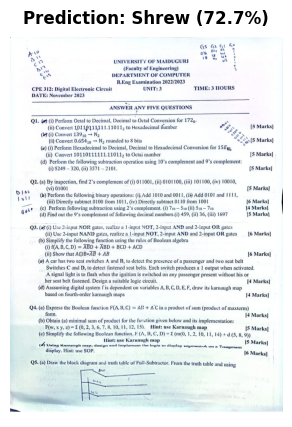

In [13]:
import torch
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
from PIL import Image
from google.colab import files
import matplotlib.pyplot as plt

def predict_new_image():
    # 1. Set backend to CPU
    device = torch.device("cpu")

    # 2. Rebuild the exact model structure used during training
    inference_model = models.resnet18()
    num_features = inference_model.fc.in_features
    inference_model.fc = nn.Sequential(
        nn.Linear(num_features, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, len(class_names)) # Reads dynamically from your Step 2 data loader
    )

    # 3. Load your saved training weights
    try:
        inference_model.load_state_dict(torch.load('best_model_weights.pth', map_location=device))
        inference_model.eval() # Set model to evaluation mode
        print("💾 Trained weights successfully loaded into model structure.")
    except FileNotFoundError:
        print("❌ Error: 'best_model_weights.pth' not found. Please make sure Step 4 completed successfully.")
        return

    # 4. Trigger file upload widget for your test image
    print("\n📸 Upload an image to test your model's classification prediction:")
    uploaded = files.upload()

    if not uploaded:
        print("❌ No image file selected.")
        return

    img_path = list(uploaded.keys())[0]

    # 5. Preprocess the image exactly like the validation set
    eval_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    raw_image = Image.open(img_path).convert('RGB')
    input_tensor = eval_transform(raw_image).unsqueeze(0) # Add batch dimension

    # 6. Run prediction pass
    with torch.no_grad():
        outputs = inference_model(input_tensor)
        probabilities = torch.nn.functional.softmax(outputs[0], dim=0)
        confidence, class_idx = torch.max(probabilities, 0)

    # ---------------------------------------------------------------------
    # SECURITY ANOMALY FILTER (THRESHOLD RUN)
    # ---------------------------------------------------------------------
    CONFIDENCE_THRESHOLD = 0.70  # 70% threshold. Adjust this based on testing!
    confidence_pct = confidence.item() * 100

    if confidence.item() < CONFIDENCE_THRESHOLD:
        predicted_label = "VOID"
        display_title = f"Result: VOID (Low Confidence: {confidence_pct:.1f}%)"
    else:
        predicted_label = class_names[class_idx.item()]
        display_title = f"Prediction: {predicted_label} ({confidence_pct:.1f}%)"

    # 7. Print the final visual summary
    print("\n==================================================")
    print("              MODEL INFERENCE RESULT              ")
    print("==================================================")
    if predicted_label == "VOID":
        print(f"⚠️ Result:               👉  {predicted_label}  👈")
        print(f"ℹ️ Status:               Object falls outside dataset boundaries.")
    else:
        print(f"🎯 Predicted Category:  👉  {predicted_label}  👈")
    print(f"🛡️ Raw Network Match:    {confidence_pct:.2f}%")
    print("==================================================\n")

    # 8. Render the uploaded image with matplotlib
    plt.figure(figsize=(5, 5))
    plt.imshow(raw_image)
    plt.title(display_title, fontsize=12, fontweight='bold', color='red' if predicted_label == "VOID" else 'black')
    plt.axis('off')
    plt.show()

# Run the inference block
predict_new_image()

💾 Trained weights successfully loaded into model structure.

📸 Upload an image to test your model's classification prediction:


Saving images (5).jpg to images (5).jpg

              MODEL INFERENCE RESULT              
🎯 Predicted Category:  👉  VOID  👈
⚠️ Security Notice:     [UNRECOGNIZED ANOMALY DETECTED]
ℹ️ Status:               Object falls outside dataset boundaries.
📊 Raw Network Match:    61.87%



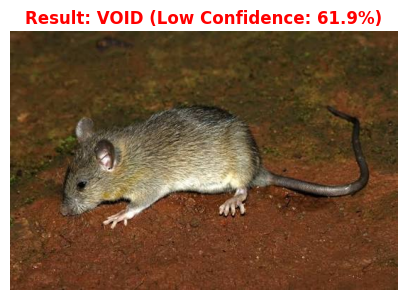

In [15]:
import torch
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
from PIL import Image
from google.colab import files
import matplotlib.pyplot as plt

def predict_new_image():
    # 1. Set backend to CPU
    device = torch.device("cpu")

    # 2. Rebuild the exact model structure used during training
    inference_model = models.resnet18()
    num_features = inference_model.fc.in_features
    inference_model.fc = nn.Sequential(
        nn.Linear(num_features, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, len(class_names)) # Reads dynamically from your Step 2 data loader
    )

    # 3. Load your saved training weights
    try:
        inference_model.load_state_dict(torch.load('best_model_weights.pth', map_location=device))
        inference_model.eval() # Set model to evaluation mode
        print("💾 Trained weights successfully loaded into model structure.")
    except FileNotFoundError:
        print("❌ Error: 'best_model_weights.pth' not found. Please make sure Step 4 completed successfully.")
        return

    # 4. Trigger file upload widget for your test image
    print("\n📸 Upload an image to test your model's classification prediction:")
    uploaded = files.upload()

    if not uploaded:
        print("❌ No image file selected.")
        return

    img_path = list(uploaded.keys())[0]

    # 5. Preprocess the image exactly like the validation set
    eval_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    raw_image = Image.open(img_path).convert('RGB')
    input_tensor = eval_transform(raw_image).unsqueeze(0) # Add batch dimension

    # 6. Run prediction pass
    with torch.no_grad():
        outputs = inference_model(input_tensor)
        probabilities = torch.nn.functional.softmax(outputs[0], dim=0)
        confidence, class_idx = torch.max(probabilities, 0)

    # ---------------------------------------------------------------------
    # SECURITY ANOMALY FILTER (THRESHOLD RUN)
    # ---------------------------------------------------------------------
    CONFIDENCE_THRESHOLD = 0.70  # 70% cutoff threshold
    confidence_pct = confidence.item() * 100

    if confidence.item() < CONFIDENCE_THRESHOLD:
        predicted_label = "VOID"
        display_title = f"Result: VOID (Low Confidence: {confidence_pct:.1f}%)"
    else:
        predicted_label = class_names[class_idx.item()]
        display_title = f"Prediction: {predicted_label} ({confidence_pct:.1f}%)"

    # 7. Print the final visual summary
    print("\n==================================================")
    print("              MODEL INFERENCE RESULT              ")
    print("==================================================")
    print(f"🎯 Predicted Category:  👉  {predicted_label}  👈")

    # Add a custom warning notice for anomalies below the category line
    if predicted_label == "VOID":
        print(f"⚠️ Security Notice:     [UNRECOGNIZED ANOMALY DETECTED]")
        print(f"ℹ️ Status:               Object falls outside dataset boundaries.")
    else:
        print(f"🛡️ Status:               Target Verified.")

    print(f"📊 Raw Network Match:    {confidence_pct:.2f}%")
    print("==================================================\n")

    # 8. Render the uploaded image with matplotlib
    plt.figure(figsize=(5, 5))
    plt.imshow(raw_image)
    plt.title(display_title, fontsize=12, fontweight='bold', color='red' if predicted_label == "VOID" else 'black')
    plt.axis('off')
    plt.show()

# Run the inference block
predict_new_image()